<a href="https://colab.research.google.com/github/pranjal7398/AI_using_Pytorch/blob/main/AI_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''PyTorch Linear Regression Model**

 Built a simple linear regression model using PyTorch to learn the relationship between input and output data.
 Implemented a single linear layer using `nn.Linear(1,1)`.
 Used Mean Squared Error (MSE) as the loss function and Adam optimizer for model training. '''

 #“a simple linear regression model using PyTorch consisting of a single linear layer that takes one input and produces one output.

import torch
import torch.nn as nn
import torch.optim as optim

class MyModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.Linear = nn.Linear(1,1)

  def forward(self,x):
    return self.Linear(x)
x = torch.tensor([[1.] , [2.] , [3.] , [4.]])
y = torch.tensor([[1.] , [4.] , [6.] , [8.]])

model = MyModel()
loss_fn = nn.MSELoss()

optimiser = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(10):
  optimiser.zero_grad()
  y_pred = model(x)
  loss = loss_fn(y_pred,y)
  loss.backward()
  optimiser.step()
  print(f"Epoch {epoch+1} , Loss : {loss.item():.4f}")


Epoch 1 , Loss : 32.4952
Epoch 2 , Loss : 28.5152
Epoch 3 , Loss : 24.8136
Epoch 4 , Loss : 21.3945
Epoch 5 , Loss : 18.2607
Epoch 6 , Loss : 15.4134
Epoch 7 , Loss : 12.8522
Epoch 8 , Loss : 10.5747
Epoch 9 , Loss : 8.5763
Epoch 10 , Loss : 6.8500


Using device  cpu
Epoch 1/5 | Loss : 320.7878
Epoch 2/5 | Loss : 133.7521
Epoch 3/5 | Loss : 93.1807
Epoch 4/5 | Loss : 69.5976
Epoch 5/5 | Loss : 55.0631
Total accuracy : 97.56%


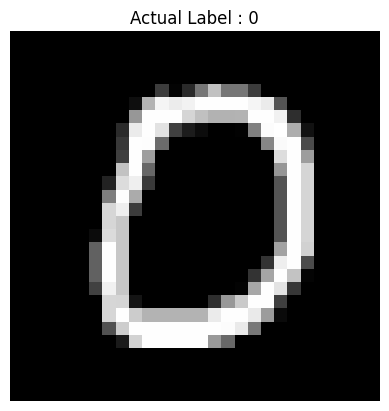

User picked image index  10
Actual Label 0
Model Prediction  0


In [8]:
# MNIST
# In this model we will give image as input and the cmodel give us a number in output by analysing the image
''' Flow - Image--> Number --> Model --> Number as output '''

# Plan
''' We use tensors
    Use dataloaders as there are more then 60 thousands of images so feeding it at once can explodes the model hence we divide it in batches and give it to the model.
    Use learning rate , activation functions , training loops etc....
'''

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device ", device)

transform = transforms.ToTensor()

train_data = MNIST(
    root = "data",
    train = True,
    download=True,
    transform = transform
)

test_data = MNIST(
    root = "data",
    train = False,
    download=True,
    transform = transform
)

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

class Digitmodel(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
        nn.Linear(28*28 , 128),
        nn.ReLU(),

        nn.Linear(128 , 64),
        nn.ReLU(),

        nn.Linear(64,10)
    )

  def forward(self ,x):
    return self.net(x)

model = Digitmodel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters() , lr=0.001)

epochs = 5
for epoch in range(epochs):
  model.train()
  total_loss = 0

  for image, labels in train_loader:
    images = image.view(image.size(0), -1).to(device)
    labels = labels.to(device)

    optimiser.zero_grad()
    outputs = model(images)
    loss = loss_fn(outputs,labels)
    loss.backward()
    optimiser.step()

    total_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs} | Loss : {total_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    images = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)

    outputs = model(images)
    predictions = outputs.argmax(dim=1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = 100 * correct/total
print(f"Total accuracy : {accuracy:.2f}%")

index = 10
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label : {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
  output = model(image_flat)
  predicted_label = output.argmax(dim=1).item()

print("User picked image index ",index)
print("Actual Label" , true_label)
print("Model Prediction ",predicted_label)




